1. Setup and Ingestion

In [ ]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for presentation charts
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

# Automatically anchors to the root 'Gen-AI' repository
# Since the notebook lives in: code/email_ingestion/notebooks/
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "Gen-AI" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

# Define portable paths relative to repo root
DATA_DIR = REPO_ROOT / "data" / "email_ingestion" / "sample emails"
GROUND_TRUTH_PATH = REPO_ROOT / "data" / "email_ingestion" / "ground_truth.csv"

# Print only the relative path for verification
print(f"Data directory located: {DATA_DIR.relative_to(REPO_ROOT)}")

# Group files and extract structural metadata
records = []
filepaths = sorted(DATA_DIR.glob("*.md"))

submission_groups = {}
for path in filepaths:
    filename = path.name
    sub_id = filename.split("_")[0]
    content = path.read_text(encoding="utf-8")
    
    file_type = "attachment" if "attachment" in filename.lower() else "email"
    submission_groups.setdefault(sub_id, []).append({
        "filename": filename,
        "file_type": file_type,
        "content": content,
        "char_count": len(content),
        "word_count": len(content.split())
    })

for sub_id, files in sorted(submission_groups.items()):
    full_text = "\n\n".join([f["content"] for f in files])
    email_files = [f for f in files if f["file_type"] == "email"]
    attachment_files = [f for f in files if f["file_type"] == "attachment"]
    
    # Check for formatting patterns in the raw markdown
    has_markdown_table = bool(re.search(r"\|.*\|.*\|", full_text))
    has_bullet_points = bool(re.search(r"^\s*[\*\-]\s+", full_text, re.MULTILINE))
    has_key_value = bool(re.search(r"^[A-Za-z\s]+:\s+.+", full_text, re.MULTILINE))
    
    # Financial token cues
    has_currency_symbol = bool(re.search(r"[£$€]", full_text))
    has_word_number = bool(re.search(r"\b(million|m|k|billion|b)\b", full_text, re.IGNORECASE))
    
    records.append({
        "submission_id": sub_id,
        "total_files": len(files),
        "has_attachment": len(attachment_files) > 0,
        "num_attachments": len(attachment_files),
        "total_words": len(full_text.split()),
        "total_chars": len(full_text),
        "estimated_tokens": int(len(full_text.split()) * 1.33),
        "has_markdown_table": has_markdown_table,
        "has_bullet_points": has_bullet_points,
        "has_key_value": has_key_value,
        "has_currency_symbol": has_currency_symbol,
        "has_word_number": has_word_number,
    })

df_eda = pd.DataFrame(records)
print(f"Successfully processed {len(df_eda)} submissions.")
df_eda.head()

Data directory located: data\email_ingestion\sample emails
Successfully processed 50 submissions.


,submission_id,total_files,has_attachment,num_attachments,total_words,total_chars,estimated_tokens,has_markdown_table,has_bullet_points,has_key_value,has_currency_symbol,has_word_number
0,E001,4,True,3,1262,7894,1678,True,True,True,True,True
1,E002,5,True,4,1072,6632,1425,True,True,True,True,True
2,E003,5,True,4,1829,11605,2432,True,True,True,True,False
3,E004,4,True,3,1244,7824,1654,True,True,True,True,True
4,E005,3,True,2,740,4378,984,True,True,True,True,True


2. Document Complexity & Length Distribution

--- Word Count and Token Summary ---


,total_words,estimated_tokens,total_files
count,50.000000,50.00000,50.00000
mean,1146.700000,1524.68000,3.52000
std,383.501018,510.06796,0.99468
min,545.000000,724.00000,2.00000
25%,875.500000,1163.75000,3.00000
50%,1082.500000,1439.50000,3.00000
75%,1500.000000,1994.50000,4.00000
90%,1671.000000,2222.00000,5.00000
95%,1782.650000,2370.35000,5.00000
max,1867.000000,2483.00000,5.00000


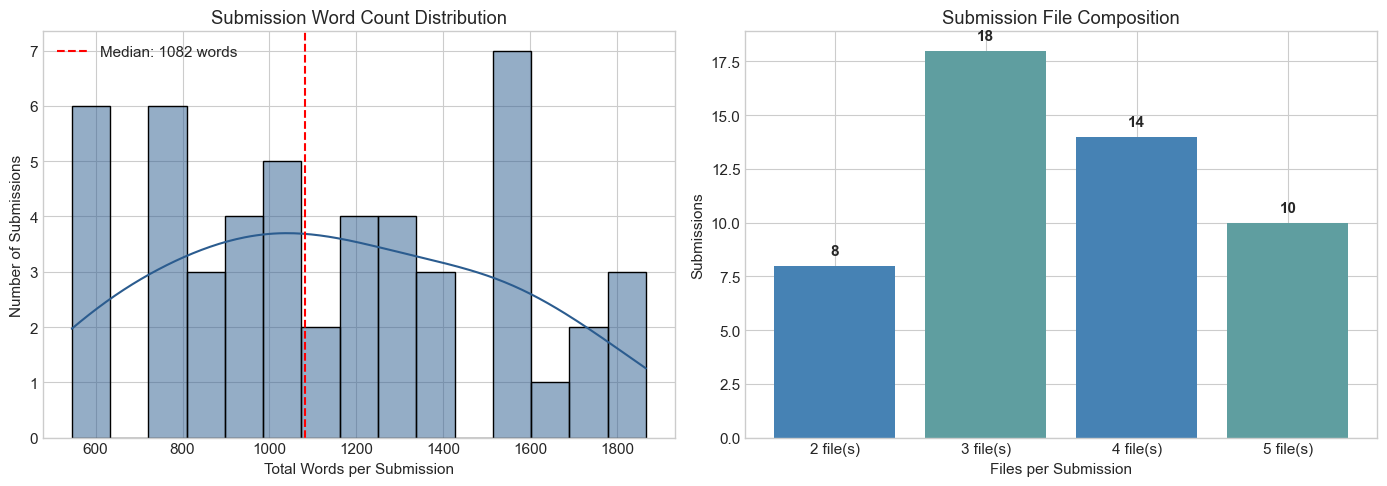

In [ ]:
# Summary statistics
print("--- Word Count and Token Summary ---")
display(df_eda[["total_words", "estimated_tokens", "total_files"]].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]))

# Plot word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
sns.histplot(df_eda["total_words"], bins=15, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].axvline(df_eda["total_words"].median(), color="red", linestyle="--", label=f"Median: {df_eda['total_words'].median():.0f} words")
axes[0].set_title("Submission Word Count Distribution")
axes[0].set_xlabel("Total Words per Submission")
axes[0].set_ylabel("Number of Submissions")
axes[0].legend()

# Attachment breakdown
attachment_counts = df_eda["total_files"].value_counts().sort_index()
axes[1].bar([f"{k} file(s)" for k in attachment_counts.index], attachment_counts.values, color=["#4682b4", "#5f9ea0"])
axes[1].set_title("Submission File Composition")
axes[1].set_xlabel("Files per Submission")
axes[1].set_ylabel("Submissions")
for i, v in enumerate(attachment_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

3. Structural Heterogeneity Analysis

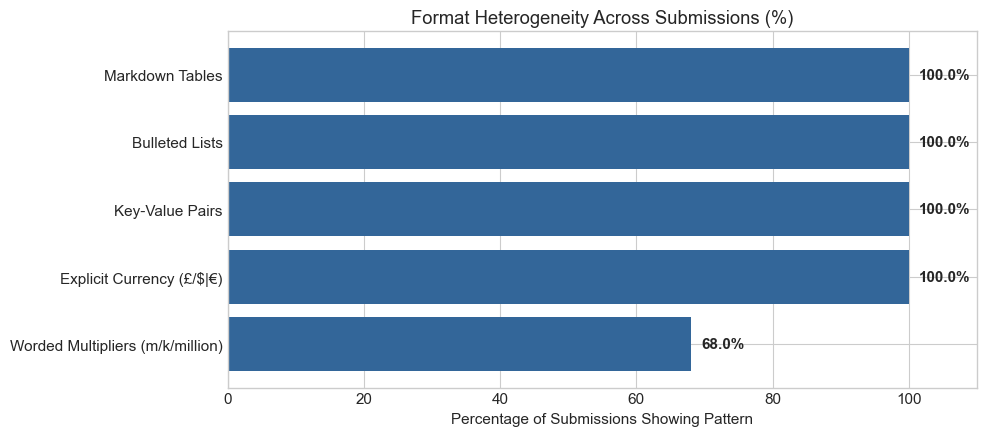

In [3]:
structure_metrics = {
    "Markdown Tables": df_eda["has_markdown_table"].mean() * 100,
    "Bulleted Lists": df_eda["has_bullet_points"].mean() * 100,
    "Key-Value Pairs": df_eda["has_key_value"].mean() * 100,
    "Explicit Currency (£/$|€)": df_eda["has_currency_symbol"].mean() * 100,
    "Worded Multipliers (m/k/million)": df_eda["has_word_number"].mean() * 100,
}

df_structure = pd.DataFrame(list(structure_metrics.items()), columns=["Pattern", "Prevalence (%)"])

plt.figure(figsize=(10, 4.5))
bars = plt.barh(df_structure["Pattern"], df_structure["Prevalence (%)"], color="#336699")
plt.xlim(0, 110)
plt.title("Format Heterogeneity Across Submissions (%)")
plt.xlabel("Percentage of Submissions Showing Pattern")

for bar in bars:
    w = bar.get_width()
    plt.text(w + 1.5, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", fontweight="bold")

plt.gca().invert_yaxis()
plt.show()